In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
with open ('physical_activities.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.head())

  ParentLocationCode SpatialDim      Dim1             Value  NumericValue  \
0                AFR        CMR  SEX_FMLE   24.1 [7.8-48.6]     24.132677   
1                EUR        FIN   SEX_MLE  18.7 [13.9-24.3]     18.734316   
2                NaN        AFR   SEX_MLE  14.5 [10.5-19.6]     14.464166   
3                AMR        PAN   SEX_MLE  35.1 [18.1-54.8]     35.101978   
4                EMR        BHR  SEX_FMLE  40.1 [14.7-69.4]     40.142845   

                            Date IndicatorCode  
0  2024-06-21T13:42:48.827+02:00       NCD_PAA  
1  2024-06-21T13:42:48.827+02:00       NCD_PAA  
2  2024-06-21T13:42:48.827+02:00       NCD_PAA  
3  2024-06-21T13:42:48.827+02:00       NCD_PAA  
4  2024-06-21T13:42:48.827+02:00       NCD_PAA  


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 35523 entries, 0 to 35522
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ParentLocationCode  33477 non-null  str    
 1   SpatialDim          35523 non-null  str    
 2   Dim1                35523 non-null  str    
 3   Value               35523 non-null  str    
 4   NumericValue        35340 non-null  float64
 5   Date                35523 non-null  str    
 6   IndicatorCode       35523 non-null  str    
dtypes: float64(1), str(6)
memory usage: 1.9 MB


,NumericValue
count,35340.000000
mean,37.513842
std,25.051738
min,1.700936
25%,19.381218
50%,28.304630
75%,45.817523
max,97.202330


In [4]:
df['NumericValue'].isnull().sum()

np.int64(183)

In [5]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

35523
35340
0


In [6]:
# #remove indicators that not relevant
# unrelated = set(['NCD_GLUC_01', 'NCD_GLUC_02', 'NCD_GLUC_03', 'NCD_GLUC_04', 'SA_0000001421','SA_0000001440'])
# df = df[~df['IndicatorCode'].isin(unrelated)]

In [7]:
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)

['NCD_PAA', 'NCD_PAC', 'NCD_PAC_ADO']


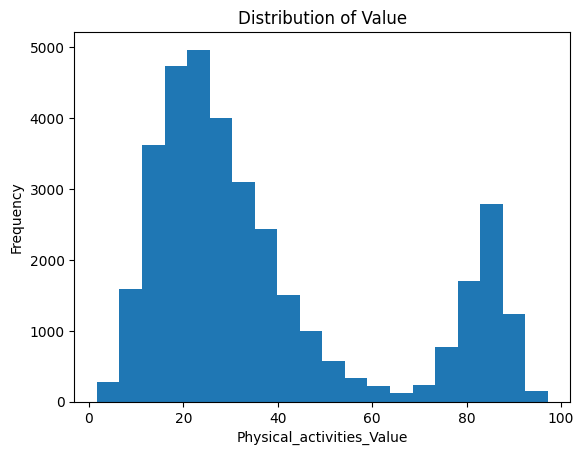

In [8]:
plt.figure()
plt.hist(df["NumericValue"], bins=20)
plt.xlabel("Physical_activities_Value")
plt.ylabel("Frequency")
plt.title("Distribution of Value")
plt.show()


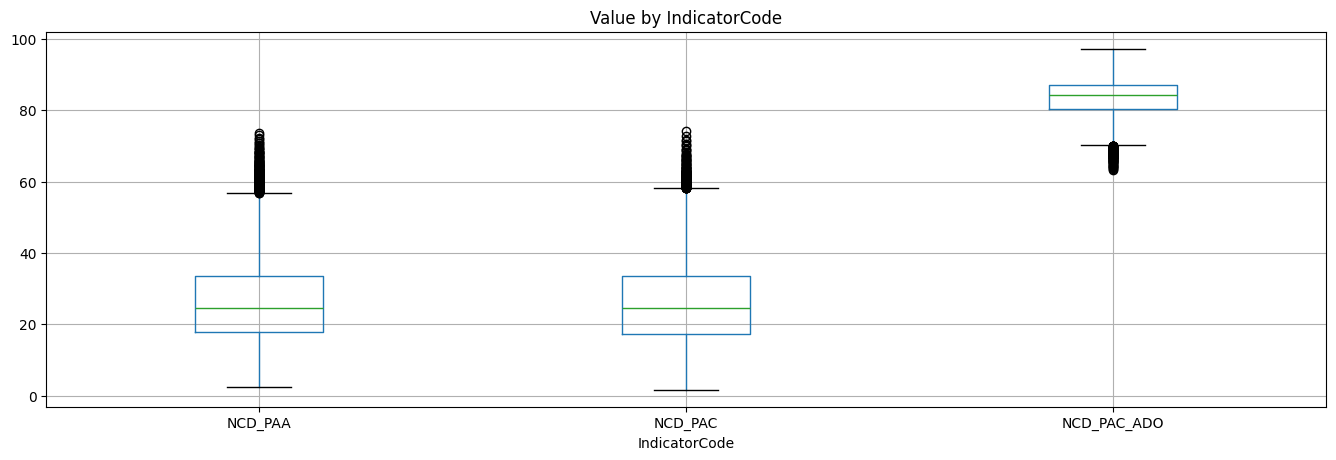

In [9]:
fig, ax = plt.subplots(figsize=(16,5))
df.boxplot(column="NumericValue", by="IndicatorCode", ax=ax)

ax.set_title("Value by IndicatorCode")
plt.suptitle("")
plt.show()